# Practical Aspects of Deep Learning

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

## Initialization

We initialize the weights randomly from the distribution $\mathcal{N}(0,\epsilon^2)$, where $\epsilon$ depends on the activation function we use, and the number of parameters.

In particular, if the activation function is $\text{ReLU}$, then
$$
\begin{align}
    \epsilon = \sqrt{\frac{2}{M}}\tag{He Initialization}
\end{align}
$$

Where $M$ is the number of parameters connecting the node $a_{i}^{[l]}$ with the nodes in the previous layer $a_{1}^{[l-1]},\dots,a_{M}^{[l-1]}$.

For the bias parameters, we set them to small positive values.

In [2]:
# Implementation
# given the dimension of the current and previous layer
def he_initialization(dim, dim_prev, rng: np.random._generator.Generator, bias_init=0.001):
    """
    He Initialization for the parameters of a given layer. It is assumed that the activation function for the layer is ReLU.

    :param dim: int; dimension of the current layer
    :param dim_prev: int; dimension of previous layer.
    :param bias_init: float; initial value for the bias.
    :param rng: np.random._generator.Generator; random number generator
    :return: tuple; (weight, bias) where weights is a numpy array of shape (dim, dim_prev) and bias is a numpy array of shape (dim, 1).
    """
    epsilon = np.sqrt(2/dim_prev)

    weights = rng.normal(loc=0, scale=epsilon, size=(dim, dim_prev))
    bias = np.ones(shape=(dim, 1)) * bias_init
    return weights, bias

### Example - naive initialization vs He initialization
In the example, we will consider
1. 1000 examples from the MNIST dataset.
2. A feedforward neural network with
    1. 5 hidden layers
    2. 100 hidden units per layer

In [3]:
# Implementation
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import struct

def linear_forward(a,w,b):
    """
    :param a: 2d np.ndarray representing the activations of the previous layer
    :param w: 2d np.ndarray representing the weights of the current layer; w.shape[1] must be equal to a.shape[0]
    :param b: 2d np.ndarray representing the bias of the current layer; b.shape[0] must be equal to w.shape[0]
    :return: np.ndarray of shape (w.shape[0],a.shape[1]); result of evaluating z = w @ a + b
    """
    assert len(a.shape) == 2 & len(b.shape) == 2 & len(w.shape) == 2
    assert a.shape[0] == w.shape[1] and w.shape[0] == b.shape[0]
    return w @ a + b

def relu_forward(z):
    """
    :param z: 2d np.ndarray representing the pre-activation of the current layer
    :return: np.ndarray; results of evaluating ReLU(z) = max(0,z)
    """
    assert len(z.shape) == 2
    return np.maximum(0,z)

def run_network(X, parameters: list[tuple], return_activations: bool = False):
    """
    :param X: 2d np.ndarray representing the input data
    :param parameters: list of tuples containing the weights and biases of each layer
    :param return_activations: bool; whether to return raw activation outputs or not
    :return: dict[str, float] | dict[str, tuple]; the mean of the square of the activations of each hidden layer
    """
    L = len(parameters)
    means = {}

    w_1, b_1 = parameters[0]
    z_1 = linear_forward(X, w_1, b_1)
    a = relu_forward(z_1)
    a_mean_sq = np.mean(a**2, keepdims=True)
    if return_activations:
        means['Layer 1'] = (a,np.squeeze(a_mean_sq))
    else:
        means['Layer 1'] = np.squeeze(a_mean_sq)

    for l in range(1,L):
        a_prev = a
        w = parameters[l][0]
        b = parameters[l][1]
        z = linear_forward(a_prev, w, b)
        a = relu_forward(z)
        a_mean_sq = np.mean(a**2, keepdims=True)
        if return_activations:
            means['Layer {}'.format(l+1)] = (a,np.squeeze(a_mean_sq))
        else:
            means['Layer {}'.format(l+1)] = np.squeeze(a_mean_sq)

    return means

def naive_initialization(dim, dim_prev, rng: np.random._generator.Generator, scale=0.01):
    """
    weights are initialized randomly from the standard normal distribution, scaled by `scale`, and has shape (dim, dim_prev);
    biases are initialized with zeros and has shape (dim, 1).

    :param dim: int; dimension of the current layer
    :param dim_prev: int; dimension of the previous layer
    :param scale: float; scaling factor for the weights
    :param rng: np.random._generator.Generator; random number generator
    :return: tuple (weights, biases) of np.ndarrays containing the initial weight and bias for the current layer
    """

    weights = rng.standard_normal(size=(dim, dim_prev)) * scale
    biases = np.zeros(shape=(dim, 1))

    return weights, biases

def initialize_parameters(X, layer_dims: list[int], method: str = "naive", random_state=None, **kwargs):
    """
    initialize the weights of a feed-forward neural network given input data X, dimensions of each hidden layer layer_dims, and method of initialization.
    if method is "naive", a naive initialization, using a standard normal distribution, is performed. If method is "he", the "He" initialization is performed.

    :param X: 2d np.ndarray representing the input data
    :param layer_dims: list of ints; dimensions of each hidden layer
    :param method: str "naive" or "he"; default "naive"; if "naive", a standard normal distribution is used to
                    initialize the weights, and np.zeros for the biases; if "he", the "He" initialization is performed.
    :param random_state: int; random seed
    :return: list of tuples (weights, biases) for each hidden layer.
    """
    L = len(layer_dims)
    parameters = []
    scale = kwargs.get("scale", 0.01)
    bias_init = kwargs.get("bias_init", 0.001)

    # First hidden layer
    dim_prev = X.shape[0]
    dim = layer_dims[0]

    if not random_state:
        random_state = 42
    rng = np.random.default_rng(random_state)

    if method == "naive":
        weights, biases = naive_initialization(dim, dim_prev, scale=scale, rng=rng)
    else:
        weights, biases = he_initialization(dim, dim_prev, bias_init=bias_init, rng=rng)

    parameters.append((weights, biases))

    # remaining hidden layers
    for l in range(1,L):
        dim_prev = dim
        dim = layer_dims[l]

        if method == "naive":
            weights, biases = naive_initialization(dim, dim_prev, rng=rng)
        else:
            weights, biases = he_initialization(dim, dim_prev, bias_init=bias_init, rng=rng)

        parameters.append((weights, biases))

    return parameters

def load_examples_mnist(n_samples=1000,
                        images_path='data/mnist-handwritten-images/train-images.idx3-ubyte',
                        labels_path='data/mnist-handwritten-images/train-labels.idx1-ubyte',
                        random_state=None):
    """
    :param n_samples: number of samples loaded from the MNIST dataset.
    :param images_path: str; path to the image examples from the MNIST dataset.
    :param labels_path: str; path to the labels from the MNIST dataset.
    :param random_state: int; random seed
    :return: tuple; (X, y) where X is a 2d np.ndarray of shape (784, n_samples) representing the normalized features matrix and
    y is a 2d np.ndarray of shape (10, n_samples) representing the one-of-K encoded labels matrix.
    """

    with open(images_path,'rb') as f:
        _ , size = struct.unpack(">II", f.read(8))
        n_rows, n_cols = struct.unpack(">II", f.read(8))
        images = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
        images = images.reshape((size, n_rows, n_cols))

    with open(labels_path,'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
        labels = labels.reshape((size,))

    X_full = images.reshape((n_rows * n_cols, size))
    y_full = labels.reshape((1, size))
    data_combined = np.vstack((X_full, y_full))

    if not random_state:
        random_state = 42
    rng = np.random.default_rng(random_state)
    data_samp = rng.choice(data_combined, size=n_samples, replace=False, axis=1)
    X_samp = StandardScaler().fit_transform(data_samp[:-1].T).T
    y_samp = OneHotEncoder(sparse_output=False).fit_transform(data_samp[-1].reshape((n_samples, 1))).T
    return X_samp, y_samp

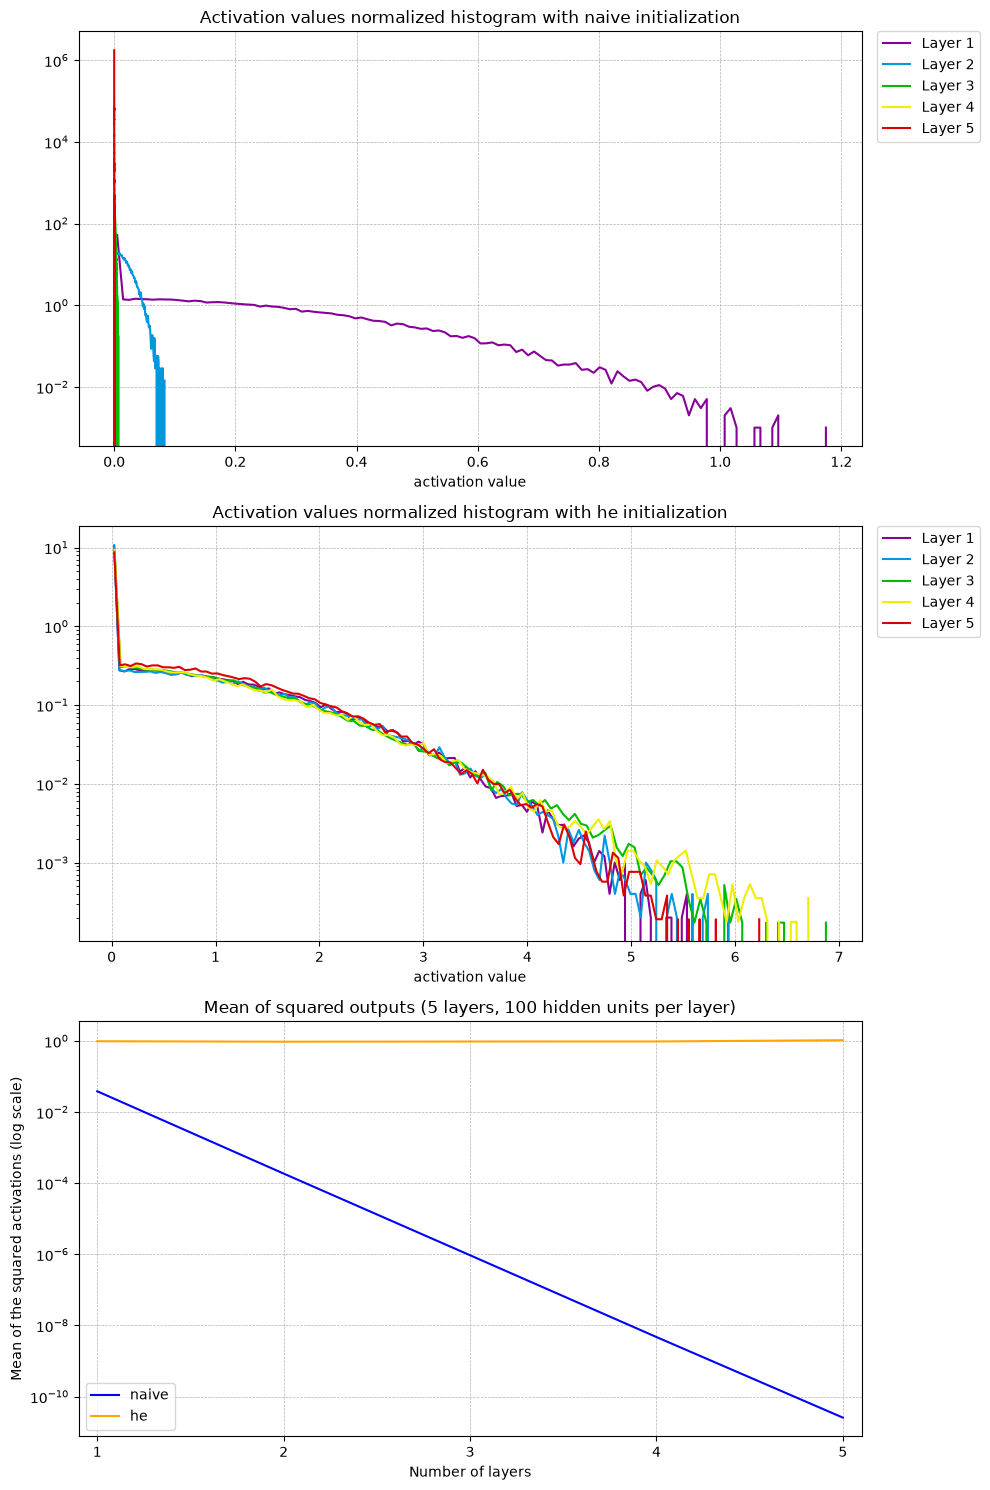

In [4]:
# Example 1
X_, y_ = load_examples_mnist()
layer_dims_ = list(100*np.ones(shape=5,dtype=int))     # Ten hidden layers, each with shape 100 and ReLU as the activation function
methods = ["naive", "he"]
random_state_ = 1
means_ = {}
kwargs_ = {'scale': 0.01, 'bias_init': 0.001}

for method_ in methods:
    parameters_ = initialize_parameters(X_, layer_dims_, method=method_, random_state=random_state_, **kwargs_)
    means_[method_] = run_network(X_, parameters_, return_activations=True)

method_colors = ["blue", "orange"]
layer_cmap = plt.get_cmap("nipy_spectral")
layer_colors = [layer_cmap(i) for i in np.linspace(0.1, 0.9, 5)]
fig, ax = plt.subplots(3,1,figsize=(10, 15))

for i, method_, ax_ in zip(range(2),methods,ax.flatten()[:-1]):
    activations, _ = zip(*means_[method_].values())
    for j, a_ in enumerate(activations):
        vals = a_.ravel()
        counts, bin_edges = np.histogram(vals, bins=120, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        ax_.plot(bin_centers, counts,
                 color=layer_colors[j],
                 linewidth=1.5,
                 label=f'Layer {j + 1}')
    ax_.set_xlabel("activation value")
    ax_.grid(visible=True, axis="both", which="major", linestyle="--", linewidth="0.5")
    ax_.set_yscale("log")
    ax_.set_title(f"Activation values normalized histogram with {method_} initialization")
    ax_.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

for color, k, v in zip(method_colors,means_.keys(),means_.values()):
    _, mean_ = zip(*v.values())
    num_layers = range(1,len(mean_)+1)
    ax[2].plot(num_layers, mean_, label=k, color=color)

ax[2].set_xlim(0.9,5.1)
ax[2].set_xticks(range(1,6,1))
ax[2].set_xlabel("Number of layers")
ax[2].set_yscale("log")
ax[2].set_ylabel("Mean of the squared activations (log scale)")
ax[2].grid(visible=True, axis="both", which="major", linestyle="--", linewidth="0.5")
ax[2].set_title("Mean of squared outputs (5 layers, 100 hidden units per layer)")
ax[2].legend(loc='best')
fig.tight_layout()
plt.show()

For the naive initialization, 0-peak increases significantly for higher layers and the distribution becomes narrower at higher layers. Furthermore, we see that the mean of the square of the outputs decrease to very small values in each subsequent layer. The conclusion from this is that the signal vanishes as we propagate forward through the network, and hence the final output carries almost no information about the input $X$.

For the HE initialization, the distributions roughly overlap and the mean remains stable across all layers so that roughly the same amount of information is retained as we propagate forward through the network. This should prove to be helpful for the convergence of the cost function.

## Regularization

In [15]:
from src.network import Network
X_train, y_train = load_examples_mnist()
n0 = X_train.shape[0]
sizes = [n0, 100, 100, 100, 100, 10]
activation_functions = ['relu', 'relu', 'relu', 'relu', 'sigmoid']

kwargs_ = {'scale': 0.1}

net = Network(sizes, activation_functions, random_state=1, init_method="he", max_epochs=int(1e3), verbose=True, **kwargs_)
net.fit(X_train, y_train)

epoch: 0, cost: 0.4889812314761274
epoch: 100, cost: 0.0205630211124552
epoch: 200, cost: 0.018532354655672288
epoch: 300, cost: 0.018018652865207253
epoch: 400, cost: 0.018012282198008406
epoch: 500, cost: 0.018008889895968116
epoch: 600, cost: 0.017508521620792975
epoch: 700, cost: 0.017506704401539397
epoch: 800, cost: 0.017505603314787576
epoch: 900, cost: 0.017504826831418043


In [16]:
y_ = np.argmax(y_train, axis=0)
score = net.score(X_train, y_)
print(f"score: {score:.2%}")

score: 96.50%
